# Modelagem Preditiva - Risco de Rebaixamento na Temporada Seguinte

## Objetivo

Este notebook trata da Fase 2 do projeto: treinar e avaliar um modelo de classificação
para a variável `rebaixado_prox_temporada`, construída e validada na Fase 1.

## Fonte dos dados

Base analítica clube-temporada, exportada do notebook 01 (EDA e preparação):
`data/processed/base_analitica_fase1.csv` (400 linhas, temporadas 2006-2025).


In [17]:
import pandas as pd
import numpy as np

base = pd.read_csv("../data/processed/base_analitica_fase1.csv")
base.shape

(400, 13)

## Remoção de linhas sem variável-alvo definida

97 linhas não têm rebaixado_prox_temporada definido (clubes já rebaixados na própria
temporada, a temporada mais recente sem sucessora disponível, ou o caso administrativo
do Barueri em 2009). Essas linhas não podem ser usadas para treinar nem avaliar o
modelo e são removidas nesta etapa.


In [18]:
base_modelo = base.dropna(subset=["rebaixado_prox_temporada"]).copy()
base_modelo["rebaixado_prox_temporada"] = base_modelo["rebaixado_prox_temporada"].astype(int)
base_modelo.shape


(303, 13)

## Seleção de variáveis explicativas (features)

Das 13 colunas da base, algumas não podem ou não devem entrar como features:

- `rebaixado_prox_temporada`: é o alvo, não uma feature.
- `posicao_prox_temporada`: foi usada para _construir_ o alvo — incluí-la como feature
  seria vazamento de dados direto (a resposta estaria dentro da pergunta).
- `clube` e `temporada`: identificadores, não variáveis de desempenho. Usá-los faria o
  modelo memorizar "quais times" ao invés de aprender "quais padrões de desempenho"
  levam ao rebaixamento — o que não generaliza para temporadas futuras.
- `jogos`: é constante (38) em todas as linhas desde 2006, não carrega informação.

As oito colunas restantes — vitórias, empates, derrotas, gols pró, gols contra, pontos,
saldo de gols e posição — formam o conjunto de features desta primeira versão do
modelo.

O split treino/teste respeita a ordem temporal (Lones, 2021, citado no Referencial
Teórico da Fase 1): treino com temporadas até 2020, teste com 2021 em diante, sem
embaralhar.


In [19]:
features = ["vitorias", "empates", "derrotas", "gols_pro", "gols_contra",
            "pontos", "saldo_gols", "posicao"]

x = base_modelo[features]
y = base_modelo["rebaixado_prox_temporada"]

corte_temporal = base_modelo["temporada"] < 2021

x_treino, x_teste = x[corte_temporal], x[~corte_temporal]
y_treino, y_teste = y[corte_temporal], y[~corte_temporal]

x_treino.shape, x_teste.shape

((239, 8), (64, 8))

In [20]:
print("Treino: ", y_treino.shape[0], "- positivos: ", y_treino.sum(),
      f"({y_treino.mean()*100:.1f}%)")

print("Teste: ", y_teste.shape[0], "- positivos: ", y_teste.sum(),
      f"({y_teste.mean()*100:.1f}%)")

Treino:  239 - positivos:  39 (16.3%)
Teste:  64 - positivos:  11 (17.2%)


## Validação Temporal (Walk-Forward)

Um único corte treino/teste (2021) deixa apenas 64 observações e 11 rebaixamentos no teste, amostra pequena demais para uma métrica confiável (menos de 5 eventos por
variável no treino).

Para aproveitar melhor os dados sem violar a ordem temporal
(LONES, 2021, citado no Referencial Teórico), o modelo é avaliado por validação
cruzada com janela expansiva: treina com todas as temporadas anteriores a T e testa
na temporada T, repetindo para T de 2014 a 2024 (11 janelas). As previsões de todas
as janelas são agregadas antes de calcular as métricas finais.

Dado o desbalanceamento da variável-alvo (~17% de positivos), o modelo é treinado
com `class_weight="balanced"`, que prioriza identificar rebaixamentos reais (recall) em vez de apenas minimizar erros, escolha justificada pelo uso de negócio: um sistema de alerta de risco é mais útil quando captura a maioria das quedas reais, mesmo ao custo de mais falsos positivos.


Precisão:  0.26
Recall:  0.769
F1:  0.388


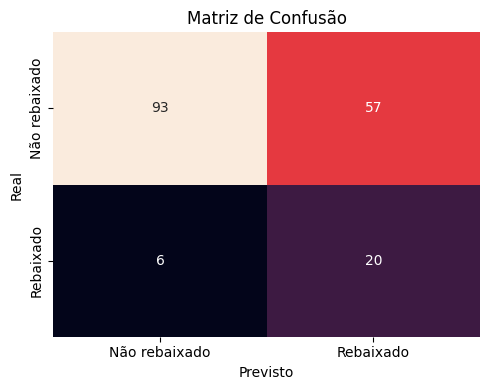

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

temporadas = sorted(base_modelo["temporada"].unique())
inicio_teste = temporadas[8] #as primeiras temporadas para treino inicial (2006 - 20013)

y_real, y_pred = [], []

for t_teste in [t for t in temporadas if t >= inicio_teste]:
  treino = base_modelo[base_modelo["temporada"] < t_teste]
  teste = base_modelo[base_modelo["temporada"] == t_teste]

  modelo = LogisticRegression(max_iter=1000, class_weight="balanced")
  modelo.fit(treino[features], treino["rebaixado_prox_temporada"])
  pred = modelo.predict(teste[features])

  y_real.extend(teste["rebaixado_prox_temporada"].tolist())
  y_pred.extend(pred.tolist())

print("Precisão: ", round(precision_score(y_real, y_pred), 3))
print("Recall: ", round(recall_score(y_real, y_pred), 3))
print("F1: ", round(f1_score(y_real, y_pred), 3))


cm = confusion_matrix(y_real, y_pred)
cmap_verde_vermelho = LinearSegmentedColormap.from_list("verde_vermelho", ["#2ecc71", "#e74c3c"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False,
            xticklabels=["Não rebaixado", "Rebaixado"],
            yticklabels=["Não rebaixado", "Rebaixado"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

### Resultado

O modelo de Regressão Logística, avaliado por validação cruzada temporal (11 janelas,
2014-2024, 176 previsões agregadas), obteve precisão de 0,26, recall de 0,77 e F1 de
0,39 com `class_weight="balanced"`. O modelo identifica corretamente 20 dos 26
rebaixamentos reais do período, ao custo de 57 falsos positivos. Essa configuração foi
escolhida em vez do modelo sem balanceamento (recall de apenas 0,15) por priorizar a
utilidade do KPI de risco como sistema de alerta: para o negócio, é preferível superestimar
risco em times seguros do que deixar de sinalizar times que de fato serão rebaixados.


## Modelo Final e Previsão para 2025

O modelo final é treinado com todas as temporadas disponíveis (2006-2024) usando uma
única variável - posição final na temporada = que, isoladamente, produziu o melhor F1
entre as combinações testadas na validação cruzada (0,369) e o único coeficiente com
sinal coerente (pior posição aumenta o risco). Isso simplifica o modelo em relação às
oito variáveis originais, mas evita a instabilidade de coeficientes causada pela
colinearidade entre pontos, posição e vitórias/empates/derrotas.

O modelo é então aplicado à temporada 2025, cujo desfecho na temporada seguinte ainda
não existe nos dados, gerando a probabilidade de rebaixamento (KPI 1). O resultado é
consolidado com o histórico 2006-2024 em um único arquivo para uso no Tableau.

**Limitação reconhecida:** este modelo testa principalmente H1 (desempenho geral como
sinal de risco). H2 (mandante/visitante) e H3 (estatísticas complementares) não estão
incorporadas nesta primeira versão, ficam como extensão natural para iteração futura,
não como hipóteses descartadas.


In [22]:
features = ["posicao"]

modelo_final = LogisticRegression(max_iter=1000, class_weight="balanced")
modelo_final.fit(base_modelo[features], base_modelo["rebaixado_prox_temporada"])

alvo_2025 = base[base["temporada"] == 2025].copy()
alvo_2025["risco_rebaixamento_previsto"] = modelo_final.predict_proba(alvo_2025[features])[:, 1]

historico = base[base["temporada"] <= 2024].copy()
historico["risco_rebaixamento_previsto"] = np.nan

export = pd.concat([historico, alvo_2025], ignore_index=True)
export = export[
  ["temporada", "clube", "jogos", "vitorias", "empates", "derrotas",
   "gols_pro", "gols_contra", "pontos", "saldo_gols", "posicao",
   "rebaixado_prox_temporada", "risco_rebaixamento_previsto"]]

export.to_csv("../data/processed/dashboard_tableu.csv", index=False)
export.shape

(400, 13)

### Resultado

O modelo final, treinado com todas as temporadas 2006-2024 usando apenas a posição
final como variável, foi aplicado à temporada 2025 para gerar o KPI de risco de
rebaixamento previsto. O arquivo consolidado data/processed/dashboard_tableau.csv foi
exportado com 400 linhas (histórico 2006-2024 com desfecho real, e 2025 com
probabilidade prevista), pronto para consumo no Tableau.

O clube com maior risco
previsto é o Sport (83,5%, 20º colocado), e o menor risco é do Flamengo (21,0%, líder).


## Correção: Previsão Histórica de Risco (2014-2024)

A primeira versão de dashboard_tableau.csv (commit da Issue #13) preenchia
risco_rebaixamento_previsto apenas para 2025, deixando 2006-2024 vazio. A decisão
inicial foi documentar isso como limitação (docs/limitacoes_modelo_fase2.md) e seguir
em frente.

Ao construir o dashboard no Tableau, essa lacuna se mostrou mais limitante na prática
do que no papel: sem previsão histórica, não é possível montar um gráfico de evolução
de risco ao longo do tempo - apenas o instantâneo de uma única temporada.

A correção não exige dado novo nem modelo novo: a validação cruzada temporal (Issue
#12) já gera, como subproduto do próprio processo de avaliação, uma previsão fora da
amostra para cada temporada de 2014 a 2024 (cada uma prevista apenas com o modelo
treinado nas temporadas anteriores a ela - sem vazamento). Essa etapa apenas
reaproveita e salva esse resultado, que antes era descartado depois de calculadas as
métricas agregadas.

O CSV final mantém a mesma estrutura de 400 linhas. A cobertura de
risco_rebaixamento_previsto passa a ser: nula em 2006-2013 (janela mínima de treino,
sem temporada anterior suficiente para gerar previsão), preenchida com previsão fora
da amostra em 2014-2024, e preenchida com o modelo final (treinado em todo o
histórico) em 2025.


In [23]:
print(type(m))
print(type(m.predict_proba))

NameError: name 'm' is not defined

In [ ]:
temporadas = sorted(base_modelo["temporada"].unique())
inicio_teste = temporadas [8]

#nova variavel para o dataset completo
previsoes_historicas = []

for t_teste in [t for t in temporadas if t >= inicio_teste]:
  treino = base_modelo[base_modelo["temporada"] < t_teste]
  teste = base_modelo[base_modelo["temporada"] == t_teste].copy()
  m = LogisticRegression(max_iter=1000, class_weight="balanced")
  m.fit(treino[features], treino["rebaixado_prox_temporada"])
  teste["risco_rebaixamento_previsto"] = m.predict_proba(teste[features])[:, 1]
  previsoes_historicas.append(teste[["temporada","clube","risco_rebaixamento_previsto"]])
previsoes_historicas = pd.concat(previsoes_historicas, ignore_index=True)

previsoes_tudo = pd.concat(
  [previsoes_historicas, alvo_2025[["temporada", "clube", "risco_rebaixamento_previsto"]]],
  ignore_index=True
)

export = base[base["temporada"] <= 2025].drop(columns=["posicao_prox_temporada"]).merge(
  previsoes_tudo, on=["temporada", "clube"], how="left"
)

export.to_csv("../data/processed/dashboard_tableu.csv", index=False)
export.groupby("temporada")["risco_rebaixamento_previsto"].apply(lambda s: s.notna().sum())

temporada
2006     0
2007     0
2008     0
2009     0
2010     0
2011     0
2012     0
2013     0
2014    16
2015    16
2016    16
2017    16
2018    16
2019    16
2020    16
2021    16
2022    16
2023    16
2024    16
2025    20
Name: risco_rebaixamento_previsto, dtype: int64

### Resultado

O CSV foi reexportado com a previsão de risco preenchida de 2014 a 2025. As
temporadas 2006-2013 permanecem sem previsão (janela mínima de treino da validação
cruzada), 2014-2024 usam a previsão fora da amostra gerada em cada janela da CV, e
2025 usa o modelo final. A base mantém as mesmas 400 linhas.
